# Llama 3.1 8B Instruct as a difficulty classifier (in-context learning)

No training: the model gets instructions (and optionally a few solved examples) in its prompt and has to answer
Easy, Medium or Hard. Runs locally on Apple Silicon with [MLX](https://github.com/ml-explore/mlx) in 4-bit
(~5 GB of memory).

**No text generation.** Instead of letting the model write an answer and searching it for "easy", we show it
the prompt and read the probability it gives to the next word being `Easy`, `Medium` or `Hard`:

```
[system: rules]  [user: example problem]  [assistant: Medium]  …  [user: new problem]  [assistant: ▢]
                                                                                              │
                                                    P(Easy) = 0.21, P(Medium) = 0.58, P(Hard) = 0.21
```

One forward pass per problem, nothing to parse, and real probabilities (the same idea as Laya). The part of the
prompt that never changes (rules + examples) is computed once and reused, so each problem only costs its own
tokens.

**Protocol, same as the other models**

| | |
|---|---|
| Test set | the shared 20% test part (`data/dataset.py`) |
| Examples in the prompt | drawn from the training part only, balanced per class, with their constraints |
| Variants | 0 examples (zero-shot) and 2 per class (6-shot) |
| Calibration | temperature + per-class bias fitted on 600 training problems (not the examples) |
| Picking the best variant | by macro-F1 on those training problems, not on the test set |
| Logging | MLflow, experiment `.../llama`, one run per variant |

In [1]:
# %pip install -qU mlx-lm scikit-learn pandas matplotlib seaborn mlflow

In [2]:
import json
import time

import matplotlib.pyplot as plt
import mlx.core as mx
import numpy as np
import pandas as pd
import seaborn as sns
from mlx_lm import load
from mlx_lm.models.cache import can_trim_prompt_cache, make_prompt_cache, trim_prompt_cache
from scipy.optimize import minimize
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

from config import CFG, set_seed
from data.dataset import LABELS, compact_statement, load_problems, report, split_indices
from tracking import log_classification, log_image, start_run

SEED = set_seed()            # CFG.seed from config.py
mx.random.seed(SEED)         # (scoring is deterministic anyway: no sampling)

# --- settings (model-specific, so they live here and not in config.py) -----------------------
MODEL = CFG.llama_model      # mlx-community/Meta-Llama-3.1-8B-Instruct-4bit (override with LLAMA_MODEL=...)
MODEL_NAME = "llama3.1-8b"   # used in run names and file names
SHOTS_PER_CLASS = [0, 2]     # 0 = zero-shot, 2 = 6 examples in the prompt
CALIB_N = 600                # training problems used to fit the calibration and to pick the variant
MEMORY_LIMIT_GB = 16         # MLX won't use more than this

mx.set_memory_limit(MEMORY_LIMIT_GB * 1024**3)
mx.set_cache_limit(2 * 1024**3)
OUT = CFG.results_dir / "llama"; OUT.mkdir(parents=True, exist_ok=True)

/Users/juraj.trappl/Documents/leetcode-difficulty-estimator/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data

The model reads the statement + constraints (no worked examples), like Laya and the RNN.

In [3]:
slugs, texts, y = load_problems()
problems = [compact_statement(t) for t in texts]
train_idx, test_idx = split_indices(y)                 # the shared test set

rng = np.random.default_rng(SEED)
max_k = max(SHOTS_PER_CLASS)
example_idx = {c: rng.choice(train_idx[y[train_idx] == c], size=max_k, replace=False) for c in range(3)}
used_as_example = np.concatenate(list(example_idx.values()))

pool = np.setdiff1d(train_idx, used_as_example)
calib_idx, _ = train_test_split(pool, train_size=min(CALIB_N, len(pool) - 3), random_state=SEED, stratify=y[pool])
print(f"examples: {[slugs[i] for i in used_as_example]}")
print(f"calibration problems: {len(calib_idx)}, test problems: {len(test_idx)}")

examples: [np.str_('employees-whose-manager-left-the-company'), np.str_('crawler-log-folder'), np.str_('combination-sum-ii'), np.str_('longest-binary-subsequence-less-than-or-equal-to-k'), np.str_('maximum-building-height'), np.str_('minimum-weighted-subgraph-with-the-required-paths')]
calibration problems: 600, test problems: 474


## 2. Prompt

A proper Llama 3 chat: a system message with the rules, each example as a user turn (the problem) followed by an
assistant turn (its label), then the new problem.

In [4]:
SYSTEM = """You are an experienced competitive programmer. You rate LeetCode problems the way LeetCode labels them.
Easy: a direct implementation or one basic idea (loop, hash map, two pointers, simple math); small inputs.
Medium: a standard algorithm or data structure applied with care (BFS/DFS, binary search, heap, sorting, basic dynamic programming).
Hard: several ideas combined or an advanced technique (hard dynamic programming, segment tree, advanced graph algorithms) under tight constraints.
Answer with exactly one word: Easy, Medium or Hard."""

def user_turn(problem):
    return {"role": "user", "content": f"Problem:\n{problem}\n\nDifficulty?"}

def messages(k):
    # system + k examples per class, interleaved (Easy, Medium, Hard, Easy, ...) so no class sits last
    msgs = [{"role": "system", "content": SYSTEM}]
    for j in range(k):
        for c in range(3):
            i = example_idx[c][j]
            msgs += [user_turn(problems[i]), {"role": "assistant", "content": LABELS[c]}]
    return msgs

print(SYSTEM)

You are an experienced competitive programmer. You rate LeetCode problems the way LeetCode labels them.
Easy: a direct implementation or one basic idea (loop, hash map, two pointers, simple math); small inputs.
Medium: a standard algorithm or data structure applied with care (BFS/DFS, binary search, heap, sorting, basic dynamic programming).
Hard: several ideas combined or an advanced technique (hard dynamic programming, segment tree, advanced graph algorithms) under tight constraints.
Answer with exactly one word: Easy, Medium or Hard.


## 3. Scoring

`DifficultyScorer` runs the fixed part of the prompt once and keeps its cache; for each problem it runs only the
problem's tokens, reads the probabilities of the three answer tokens, and rolls the cache back. Expect roughly
30–60 min on a Mac for both variants (calibration + test problems); results are cached, so a stopped run resumes.
`label_mass` = how much of the model's total probability went to Easy/Medium/Hard (close to 1 = it answers in the
expected format).

In [5]:
model, tokenizer = load(MODEL)

class DifficultyScorer:
    def __init__(self, k):
        self.prefix_msgs = messages(k)
        self.prefix_text = tokenizer.apply_chat_template(self.prefix_msgs, tokenize=False)
        self.label_ids = [tokenizer.encode(label, add_special_tokens=False)[0] for label in LABELS]
        assert len(set(self.label_ids)) == 3, "Easy/Medium/Hard must start with different tokens"
        self.cache = make_prompt_cache(model)
        prefix_ids = tokenizer.encode(self.prefix_text, add_special_tokens=False)
        mx.eval(model(mx.array(prefix_ids)[None], cache=self.cache))
        self.prefix_len = len(prefix_ids)
        self.reuse = can_trim_prompt_cache(self.cache)

    def __call__(self, problem):
        full = tokenizer.apply_chat_template(self.prefix_msgs + [user_turn(problem)], tokenize=False,
                                             add_generation_prompt=True)
        if self.reuse and full.startswith(self.prefix_text):
            ids = tokenizer.encode(full[len(self.prefix_text):], add_special_tokens=False)
            logits = model(mx.array(ids)[None], cache=self.cache)[0, -1]
            trim_prompt_cache(self.cache, len(ids))            # back to just the fixed prefix
        else:                                                   # fallback: run the whole prompt
            logits = model(mx.array(tokenizer.encode(full, add_special_tokens=False))[None])[0, -1]
        logp = logits.astype(mx.float32) - mx.logsumexp(logits.astype(mx.float32))
        label_logp = np.array(logp[mx.array(self.label_ids)])
        p = np.exp(label_logp - label_logp.max())
        return p / p.sum(), float(np.exp(label_logp).sum())

print("answer tokens:", [tokenizer.decode([t]) for t in DifficultyScorer(0).label_ids])

Fetching 6 files: 100%|██████████| 6/6 [01:37<00:00, 16.28s/it]
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


answer tokens: ['Easy', 'Medium', 'Hard']


In [6]:
def score_all(k):
    # probabilities for the calibration + test problems; cached in results/llama/, so a stopped run resumes
    path = OUT / f"{MODEL_NAME}_{3 * k}shot.jsonl"
    done = {}
    if path.exists():
        for line in open(path):
            r = json.loads(line); done[r["slug"]] = r
    todo = [i for i in np.concatenate([calib_idx, test_idx]) if slugs[i] not in done]
    if todo:
        scorer = DifficultyScorer(k)
        t0 = time.time()
        with open(path, "a") as f:
            for i in tqdm(todo, desc=f"{3 * k}-shot"):
                p, mass = scorer(problems[i])
                r = {"slug": str(slugs[i]), "p": p.tolist(), "label_mass": mass}
                done[r["slug"]] = r
                f.write(json.dumps(r) + "\n")
        print(f"{(time.time() - t0) / len(todo):.2f} s per problem")
    P = lambda idx: (lambda a: a / a.sum(1, keepdims=True))(np.array([done[slugs[i]]["p"] for i in idx]))
    mass = np.mean([done[slugs[i]]["label_mass"] for i in test_idx])
    return P(calib_idx), P(test_idx), mass

scores = {k: score_all(k) for k in SHOTS_PER_CLASS}

0-shot: 100%|██████████| 1074/1074 [16:30<00:00,  1.08it/s]


0.92 s per problem


6-shot: 100%|██████████| 1074/1074 [17:25<00:00,  1.03it/s]

0.97 s per problem


## 4. Calibration and results

LLMs have a *label bias* (they like one answer) and are over- or under-confident. As in the Laya notebook we fit
one temperature and one bias per class on the calibration problems (training part): new logits = log p / T + b.

In [7]:
def fit_temp_bias(P, y_true):
    L = np.log(np.clip(P, 1e-9, 1))
    def nll(w):
        T, b = np.exp(np.clip(w[0], -3, 3)), np.r_[0.0, w[1:]]        # temperature kept in [0.05, 20]
        z = L / T + b; z -= z.max(1, keepdims=True)
        return -(z - np.log(np.exp(z).sum(1, keepdims=True)))[np.arange(len(y_true)), y_true].mean()
    w = minimize(nll, np.zeros(3), method="Nelder-Mead").x
    T, b = np.exp(np.clip(w[0], -3, 3)), np.r_[0.0, w[1:]]
    def apply(P2):
        z = np.log(np.clip(P2, 1e-9, 1)) / T + b; z -= z.max(1, keepdims=True)
        e = np.exp(z); return e / e.sum(1, keepdims=True)
    return apply, T, b

def ece(P, y_true, bins=15):
    conf, correct = P.max(1), (P.argmax(1) == y_true)
    edges = np.linspace(0, 1, bins + 1)
    return sum(((conf > lo) & (conf <= hi)).mean() * abs(conf[(conf > lo) & (conf <= hi)].mean() - correct[(conf > lo) & (conf <= hi)].mean())
               for lo, hi in zip(edges[:-1], edges[1:]) if ((conf > lo) & (conf <= hi)).any())

y_calib, y_test = y[calib_idx], y[test_idx]
rows, preds = [], {}
for k, (P_calib, P_test, mass) in scores.items():
    cal, T, b = fit_temp_bias(P_calib, y_calib)
    for kind, Pc, Pt in [("raw", P_calib, P_test), ("calibrated", cal(P_calib), cal(P_test))]:
        name = f"{3 * k}-shot {kind}"
        preds[name] = Pt
        m = report(y_test, Pt.argmax(1), name=f"{name} (test)")
        rows.append({"variant": name, "shots": 3 * k, "kind": kind,
                     "calib_macro_f1": report(y_calib, Pc.argmax(1), name=f"{name} (calibration)")["macro_f1"],
                     **{f"test_{key}": v for key, v in m.items()},
                     "test_log_loss": log_loss(y_test, Pt, labels=[0, 1, 2]), "test_ece": ece(Pt, y_test),
                     "label_mass": mass, "T": T, "bias": np.round(b, 2).tolist()})

table = pd.DataFrame(rows).set_index("variant")
table.to_csv(CFG.results_dir / f"{MODEL_NAME}_results.csv", float_format="%.4f")
print("\nalways Medium on the test set: accuracy 0.511, macro-F1 0.225")
table

0-shot raw (test): accuracy 0.544, macro_f1 0.369, qwk 0.217
0-shot raw (calibration): accuracy 0.563, macro_f1 0.385, qwk 0.213
0-shot calibrated (test): accuracy 0.549, macro_f1 0.470, qwk 0.363
0-shot calibrated (calibration): accuracy 0.582, macro_f1 0.495, qwk 0.362
6-shot raw (test): accuracy 0.589, macro_f1 0.585, qwk 0.563
6-shot raw (calibration): accuracy 0.630, macro_f1 0.626, qwk 0.582
6-shot calibrated (test): accuracy 0.637, macro_f1 0.572, qwk 0.531
6-shot calibrated (calibration): accuracy 0.642, macro_f1 0.583, qwk 0.540

always Medium on the test set: accuracy 0.511, macro-F1 0.225


,shots,kind,calib_macro_f1,test_accuracy,test_macro_f1,test_qwk,test_log_loss,test_ece,label_mass,T,bias
variant,,,,,,,,,,,
0-shot raw,0,raw,0.385351,0.544304,0.368621,0.216665,1.030906,0.221926,0.999340,1.739534,"[0.0, -0.73, -0.46]"
0-shot calibrated,0,calibrated,0.494582,0.548523,0.470494,0.362687,0.868678,0.048684,0.999340,1.739534,"[0.0, -0.73, -0.46]"
6-shot raw,6,raw,0.625920,0.588608,0.585474,0.562805,0.873490,0.142276,0.998253,1.734515,"[0.0, -0.44, -1.22]"
6-shot calibrated,6,calibrated,0.583430,0.637131,0.571669,0.530620,0.753976,0.047200,0.998253,1.734515,"[0.0, -0.44, -1.22]"


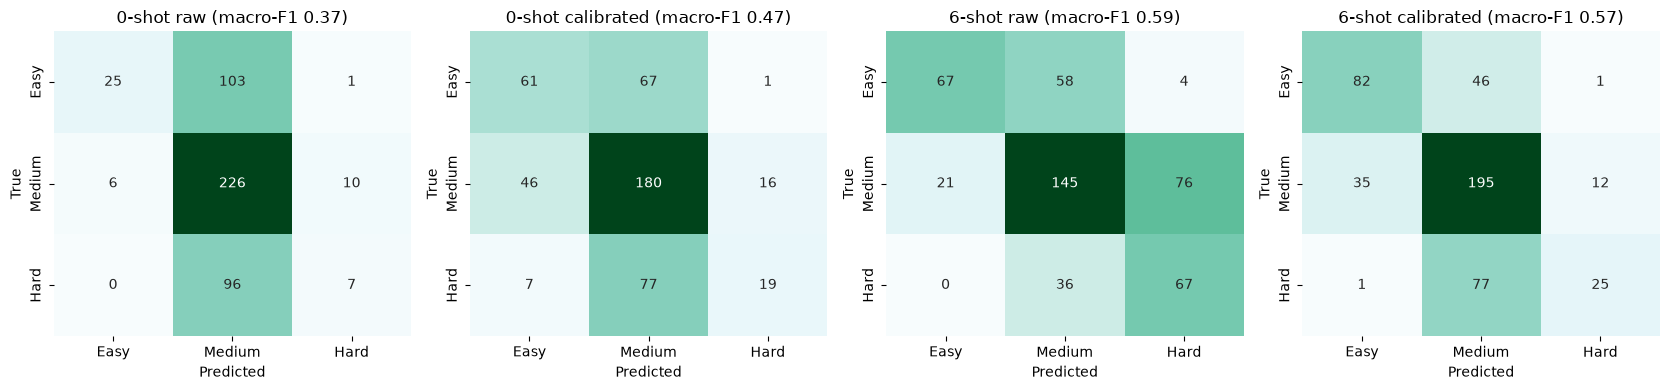

best variant (by calibration-set macro-F1): 6-shot raw


In [8]:
fig, axes = plt.subplots(1, len(preds), figsize=(4.2 * len(preds), 4), squeeze=False)
for ax, (name, Pt) in zip(axes[0], preds.items()):
    cm = pd.crosstab(y_test, Pt.argmax(1)).reindex(index=[0, 1, 2], columns=[0, 1, 2]).fillna(0).astype(int).values
    sns.heatmap(cm, annot=True, fmt="d", cmap="BuGn", xticklabels=LABELS, yticklabels=LABELS, cbar=False, ax=ax)
    ax.set_title(f"{name} (macro-F1 {table.loc[name, 'test_macro_f1']:.2f})")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
fig.tight_layout()
fig.savefig(CFG.figures_dir / f"{MODEL_NAME}.png", dpi=CFG.fig_dpi)
plt.show()

best = table["calib_macro_f1"].idxmax()        # chosen on training problems, not on the test set
print("best variant (by calibration-set macro-F1):", best)

## 5. Log to MLflow

One run per variant: `llama-llama3.1-8b-<n>shot-s<seed>` in experiment `.../llama`, with raw and calibrated test
scores, both confusion matrices and the prompt settings.

In [9]:
for k, (P_calib, P_test, mass) in scores.items():
    raw, cal = table.loc[f"{3 * k}-shot raw"], table.loc[f"{3 * k}-shot calibrated"]
    with start_run("llama", MODEL_NAME, f"{3 * k}shot", job_type="eval", config={
            "model": MODEL, "shots_per_class": k, "examples": [slugs[example_idx[c][j]] for j in range(k) for c in range(3)],
            "calibration_problems": len(calib_idx), "system_prompt": SYSTEM, "scoring": "next-token probabilities"}) as run:
        log_classification(run, y_test, preds[f"{3 * k}-shot raw"].argmax(1), prefix="test/raw")
        log_classification(run, y_test, preds[f"{3 * k}-shot calibrated"].argmax(1), prefix="test/calibrated")
        run.summary.update({"label_mass": mass, "calibration/T": float(cal["T"]),
                            "calib/macro_f1": float(cal["calib_macro_f1"]),
                            "test/raw/log_loss": float(raw["test_log_loss"]), "test/raw/ece": float(raw["test_ece"]),
                            "test/calibrated/log_loss": float(cal["test_log_loss"]), "test/calibrated/ece": float(cal["test_ece"])})
        log_image(run, "confusion_matrices", CFG.figures_dir / f"{MODEL_NAME}.png")

test/raw: accuracy 0.544, macro_f1 0.369, qwk 0.217
test/calibrated: accuracy 0.549, macro_f1 0.470, qwk 0.363
test/raw: accuracy 0.589, macro_f1 0.585, qwk 0.563
test/calibrated: accuracy 0.637, macro_f1 0.572, qwk 0.531
